In [32]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly, find_peaks
import neurokit2 as nk
import rsp.data_processing.signal_processing as signal_processing
from rsp.plotting import Rsp_Kit

import importlib
importlib.reload(signal_processing)
importlib.reload(Rsp_Kit)

def analyze_and_plot_breathing(h5_file, target_rate=100):
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
    except Exception as e:
        return {"file": os.path.basename(h5_file), "error": str(e)}

    try:
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except KeyError:
        return {"file": os.path.basename(h5_file), "error": "Missing 'duration_sec' metadata"}

    # Step 1: Pre-downsampling apply low-pass filter
    cutoff_hz = target_rate / 2
    nyquist = fs / 2
    norm_cutoff = cutoff_hz / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Step 2: Downsample
    downsample_factor = int(fs // target_rate)
    downsampled_resp = resample_poly(filtered_resp, up=1, down=downsample_factor)
    duration_downsampled = len(downsampled_resp) / target_rate

    # Step 3: Apply neurokit2 Butterworth bandpass filter after downsampling
    rsp_cleaned = nk.signal_filter(
        downsampled_resp,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Step 4: Mask signal loss with NaN values
    signal_loss_filtered = signal_processing.mask_signal_loss(
        rsp_cleaned,
        fs=target_rate,
        window_sec=10,
        std_thresh=800,
    )

    # Step 5: Subtract total time NaNed from total duration
    total_nan_time = np.sum(np.isnan(signal_loss_filtered)) / target_rate
    duration_downsampled -= total_nan_time

    # Step 6: Peak detection | Change to match how class finds peaks
    # Find valid (non-NaN) indices
    valid = ~np.isnan(signal_loss_filtered)

    # Run peak detection only on valid values
    valid_signal = signal_loss_filtered[valid]
    peaks_valid, _ = find_peaks(valid_signal, distance=target_rate // 20)

    # Calculate valid duration again (just to be sure)
    duration_valid = np.sum(valid) / target_rate
    breathing_rate_hz = len(peaks_valid) / duration_valid

    # Step 5: Plot with Rsp_Kit
    try:
        rsp_obj = Rsp_Kit.Rsp_Kit(valid_signal, fs=target_rate, n_samples=len(valid_signal))
        print(f"Processing file: {os.path.basename(h5_file)}")
        fig = rsp_obj.plot_overlay(start_time=50, duration=50, show_peaks=True, title=os.path.basename(h5_file))

        plt.close()

    except Exception as plot_err:
        return {"file": os.path.basename(h5_file), "error": f"Plotting failed: {plot_err}"}

    return {
        "file": os.path.basename(h5_file),
        "original_fs": round(fs, 2),
        "duration_sec (before downsample and filtering)": round(duration_sec, 2),
        "downsampled_len": len(downsampled_resp),
        "duration_valid": round(duration_downsampled, 2),
        "peak_count": len(peaks_valid),
        "breathing_rate_hz": round(breathing_rate_hz, 2),
    }

def batch_analyze_directory(directory_path):
    results = []
    for file in os.listdir(directory_path):
        if file.endswith(".h5"):
            full_path = os.path.join(directory_path, file)
            result = analyze_and_plot_breathing(full_path)
            results.append(result)
    return pd.DataFrame(results)

# 👉 SET YOUR DIRECTORY PATH HERE
if __name__ == "__main__":
    directory = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\updated_meta_h5"
    df_results = batch_analyze_directory(directory)
    print(df_results.to_string(index=False))


Processing file: BLRI_s1_1_p5_2_nRB6_20250622_141846_merged.h5
Processing file: BLRI_s1_2_p5_1_nRB6_20250622_164833_merged.h5
Processing file: BLRI_s2_3_p5_3_nRB3_20250622_101813_merged.h5
Processing file: BLRI_s2_4_p5_4_nRB3_20250622_121708_merged.h5
Processing file: BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5
Processing file: BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5
Processing file: BLRI_s4_8_p5_1_nRB3_20250621_163506_merged.h5
Processing file: RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5
Processing file: RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5
Processing file: RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5
Processing file: RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5
Processing file: RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5
Processing file: RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5
Processing file: RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5
Processing file: RI1_s5_13_p5_4_nRB3_20250622_181801_merged.h5
Processing file: RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5


C:\Users\thoma\AppData\Local\Temp\ipykernel_41388\2543548487.py:73: RuntimeWarning: invalid value encountered in scalar divide
  breathing_rate_hz = len(peaks_valid) / duration_valid


Processing file: BLRI_s1_1_p5_2_nRB6_20250622_141846_merged.h5


C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\rsp\plotting\Rsp_Kit.py:415: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, alpha=0.3)


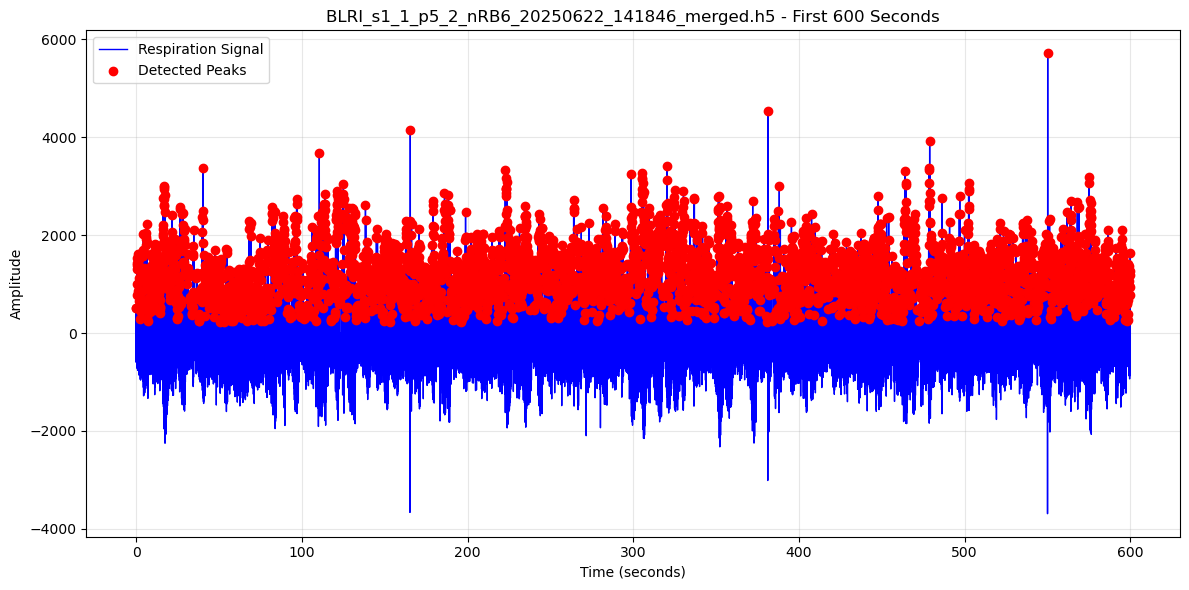

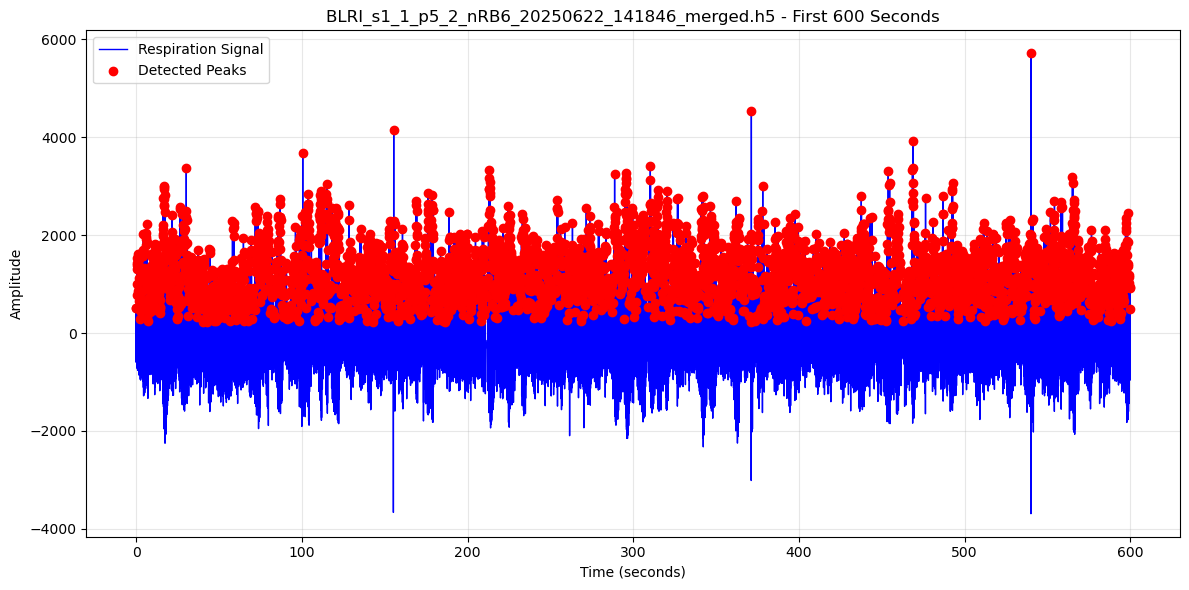

Processing file: BLRI_s1_2_p5_1_nRB6_20250622_164833_merged.h5


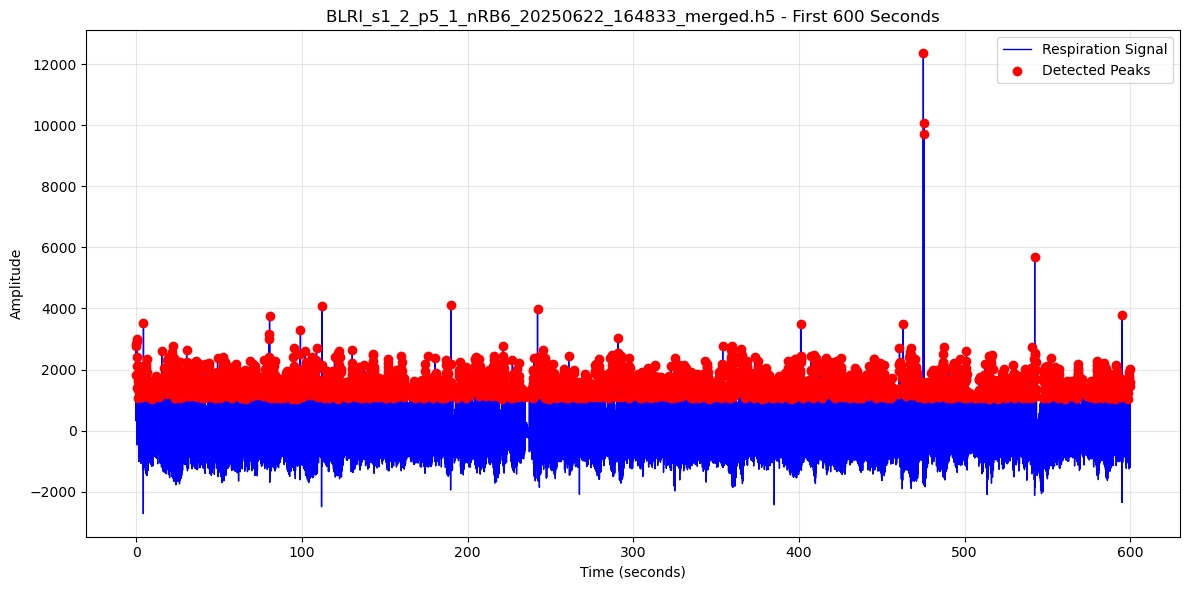

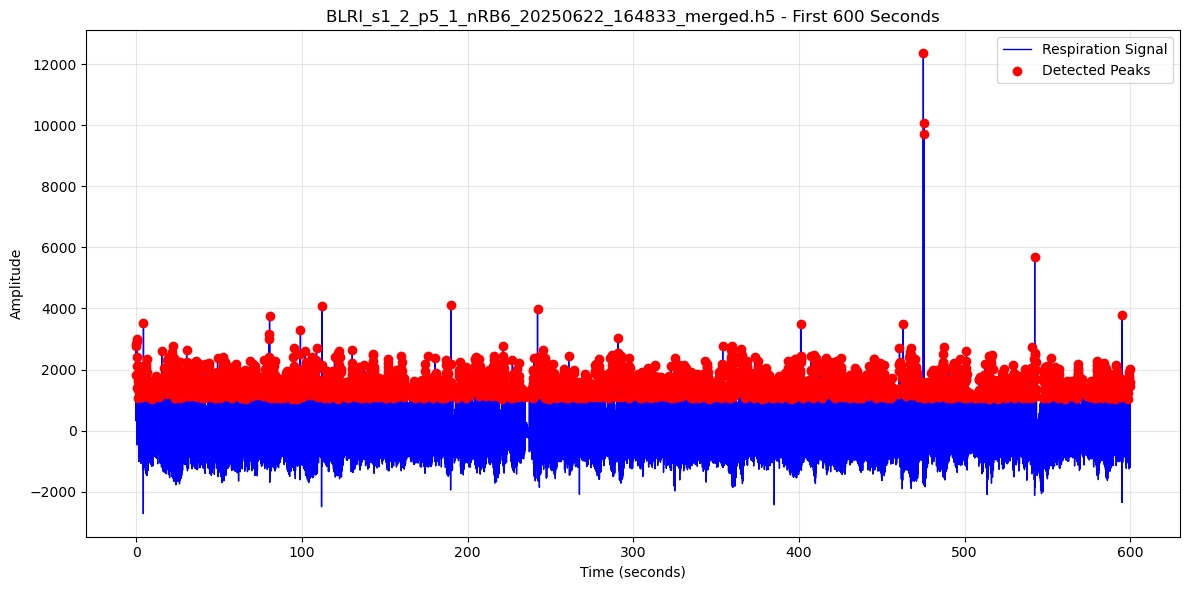

Processing file: BLRI_s2_3_p5_3_nRB3_20250622_101813_merged.h5


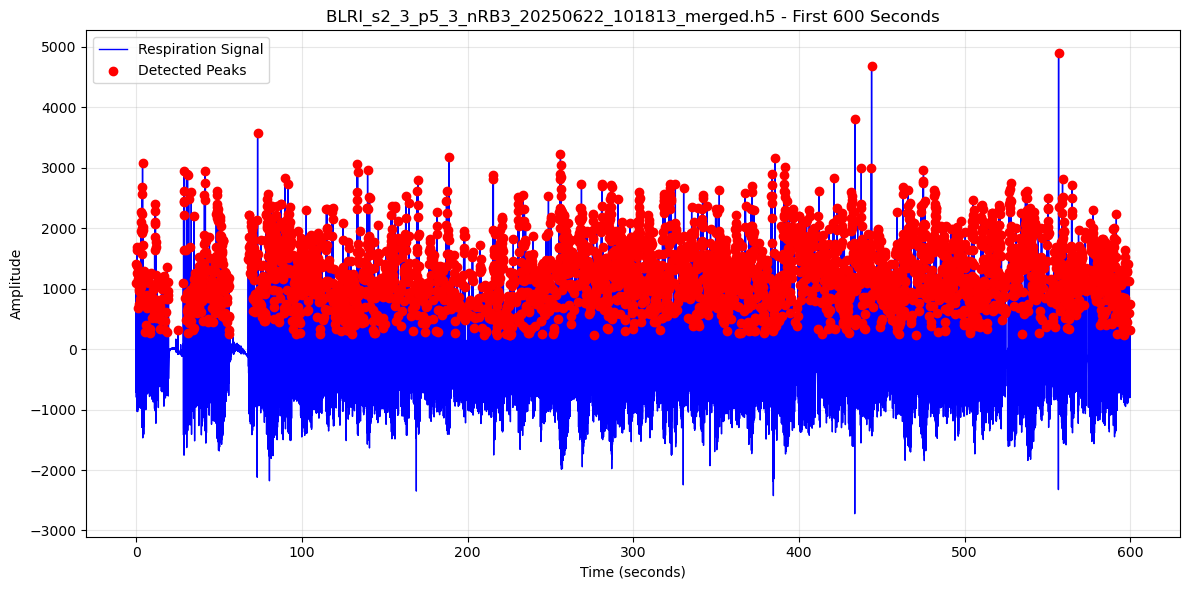

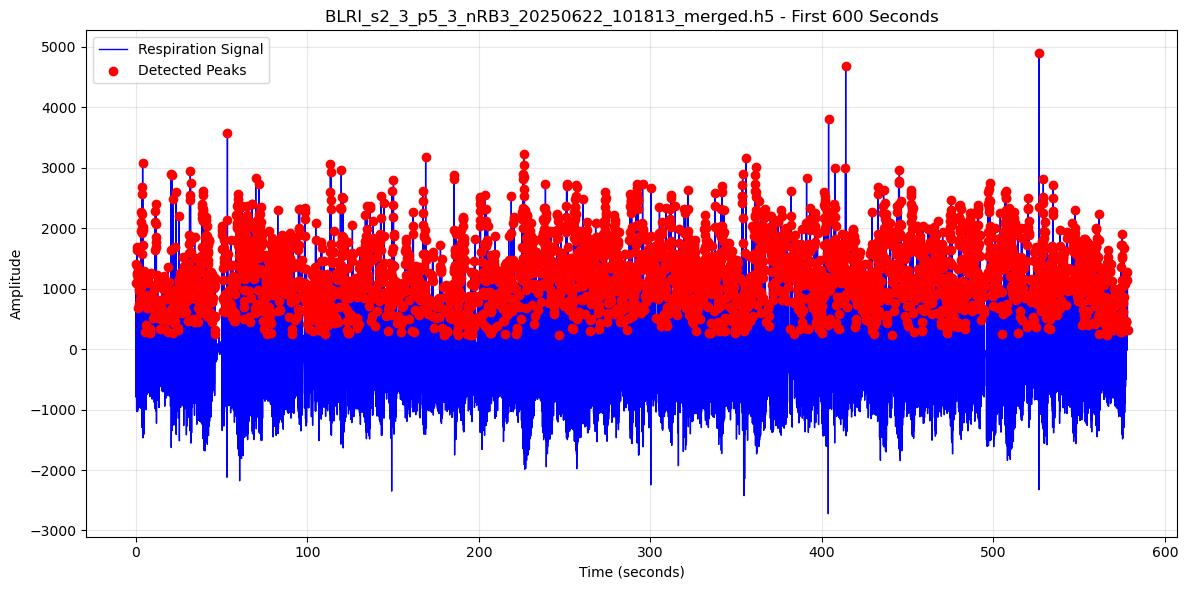

Processing file: BLRI_s2_4_p5_4_nRB3_20250622_121708_merged.h5


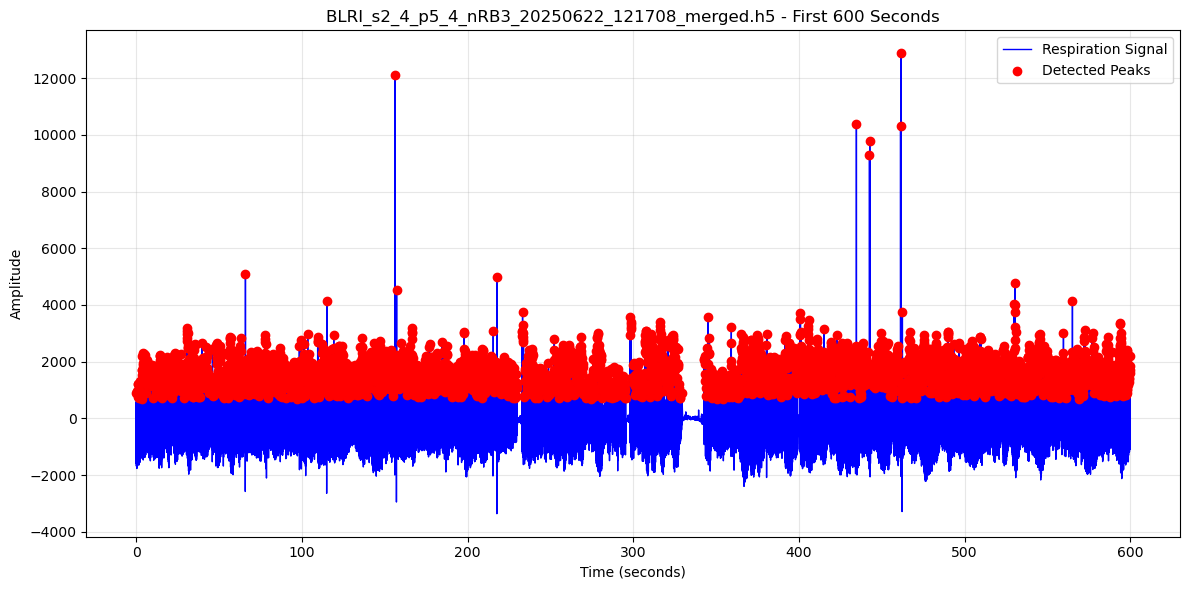

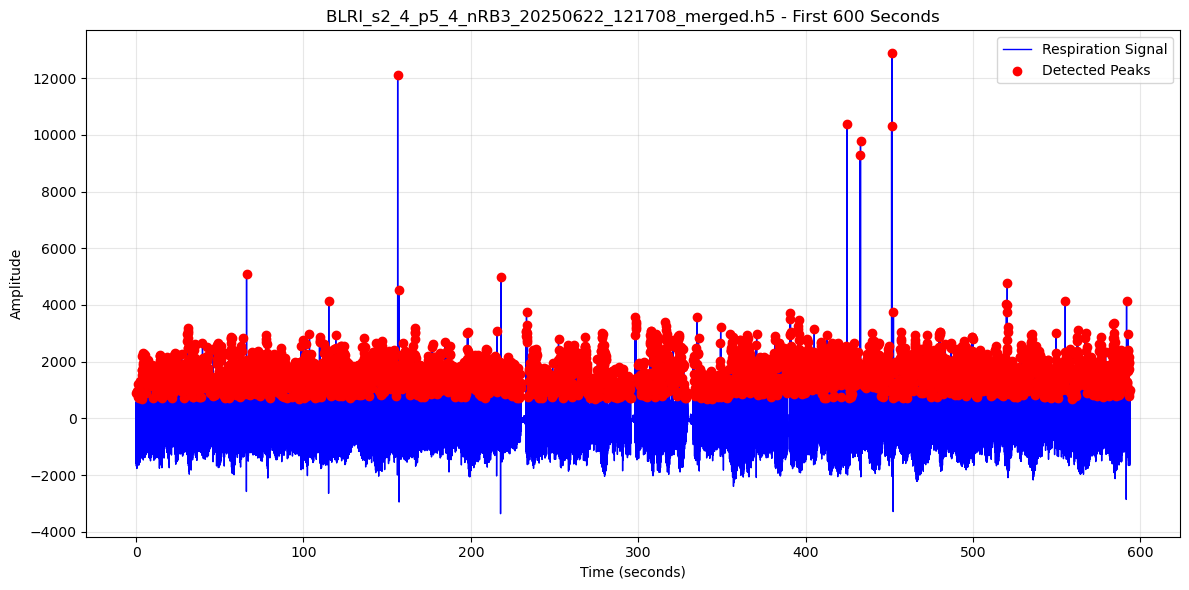

Processing file: BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5


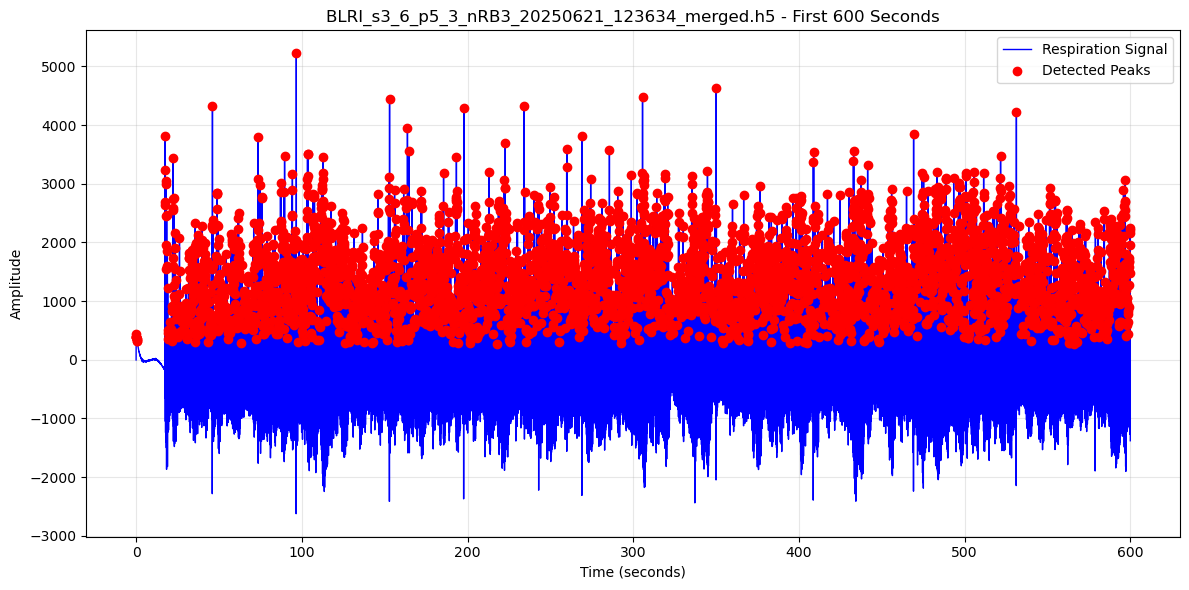

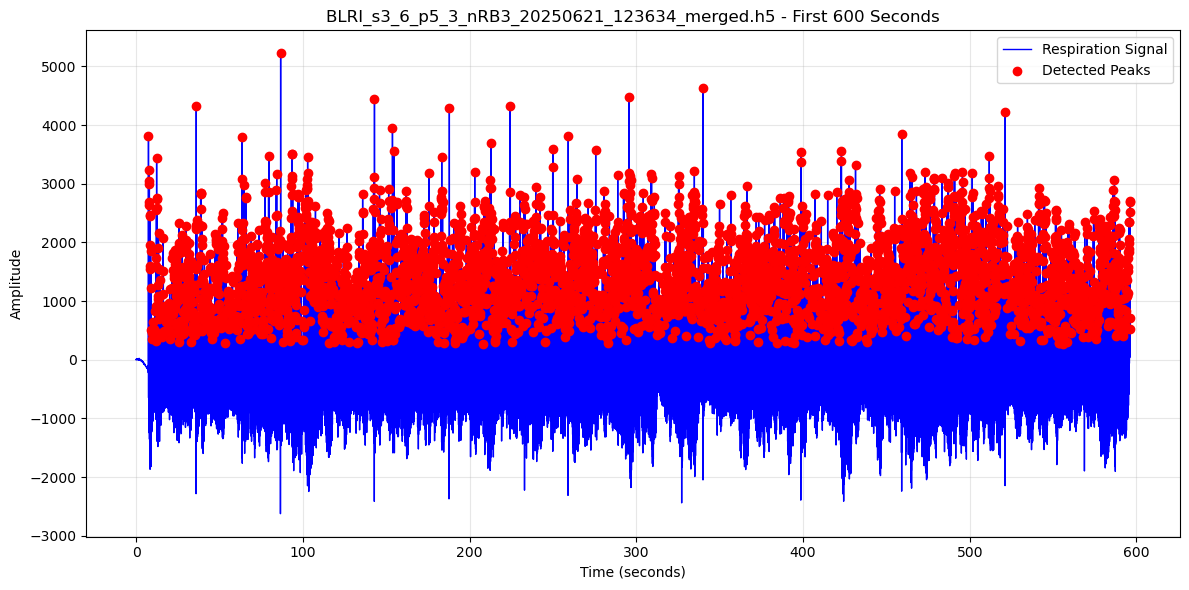

Processing file: BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5


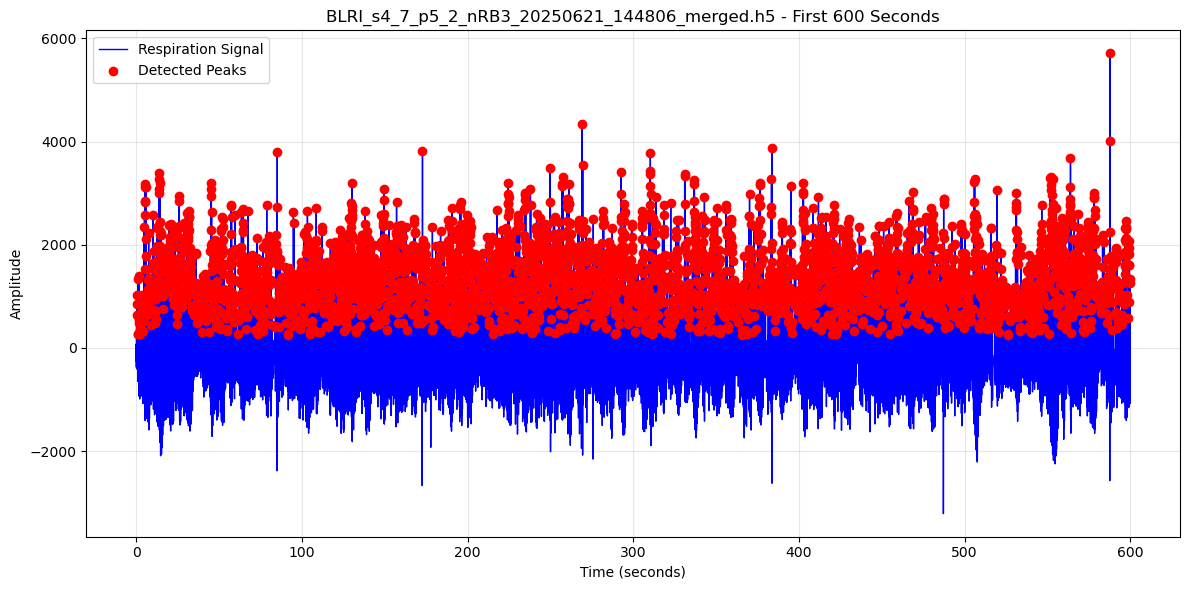

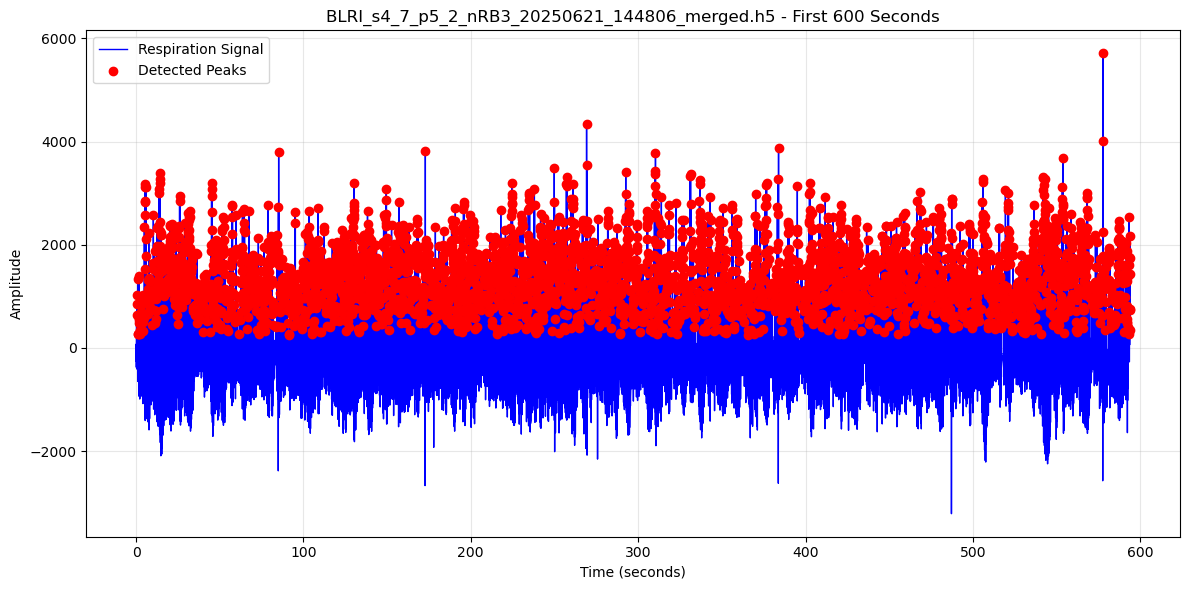

Processing file: BLRI_s4_8_p5_1_nRB3_20250621_163506_merged.h5


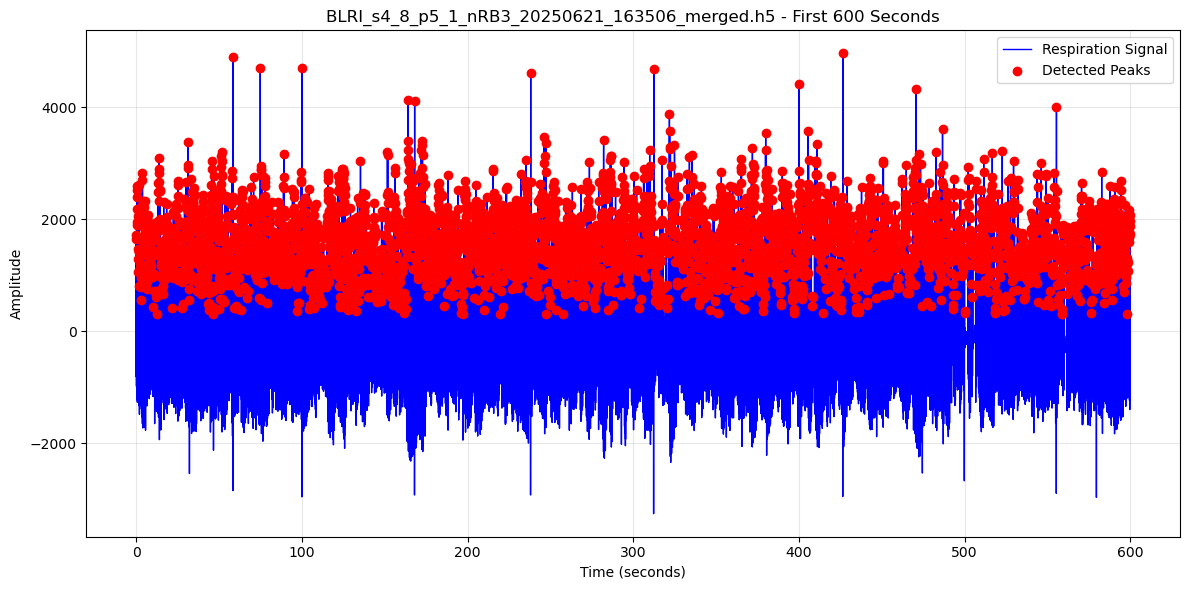

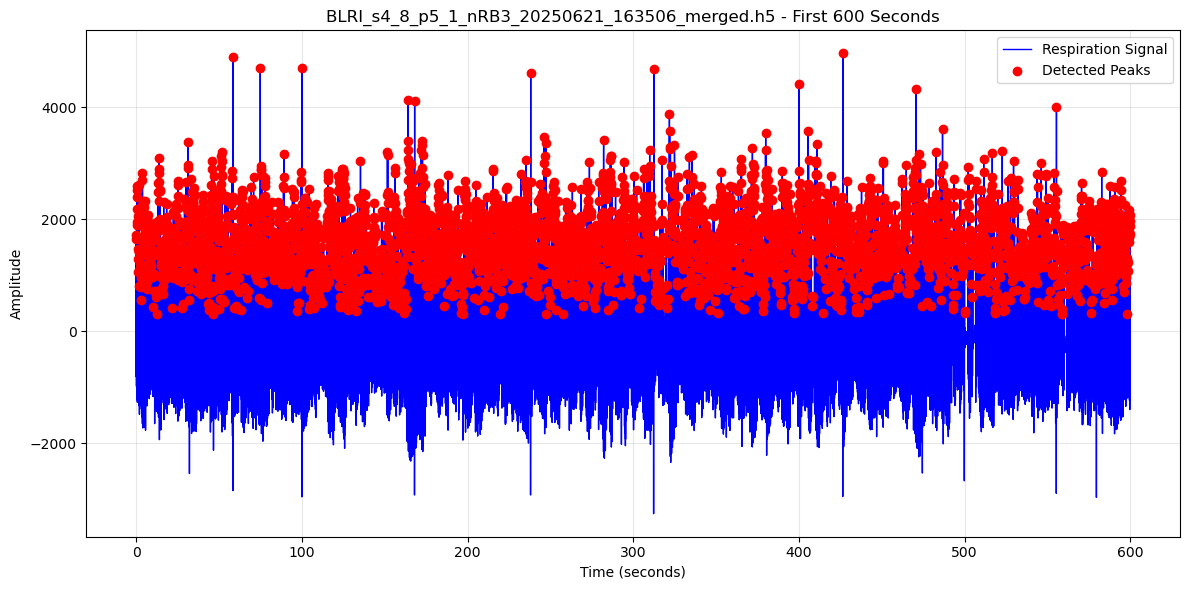

Processing file: RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5


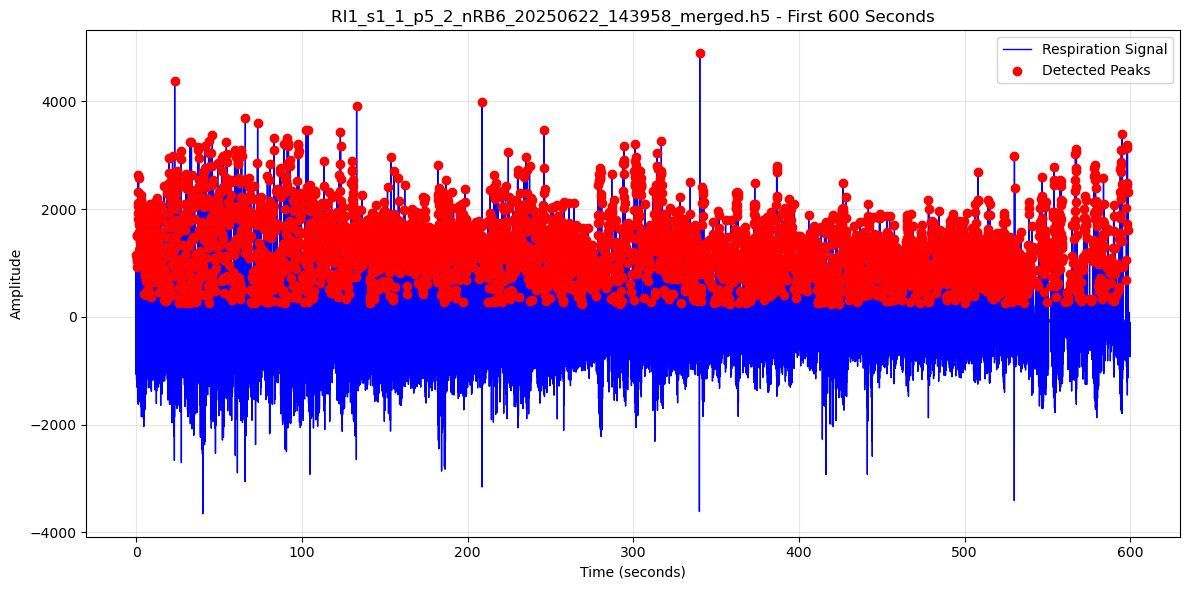

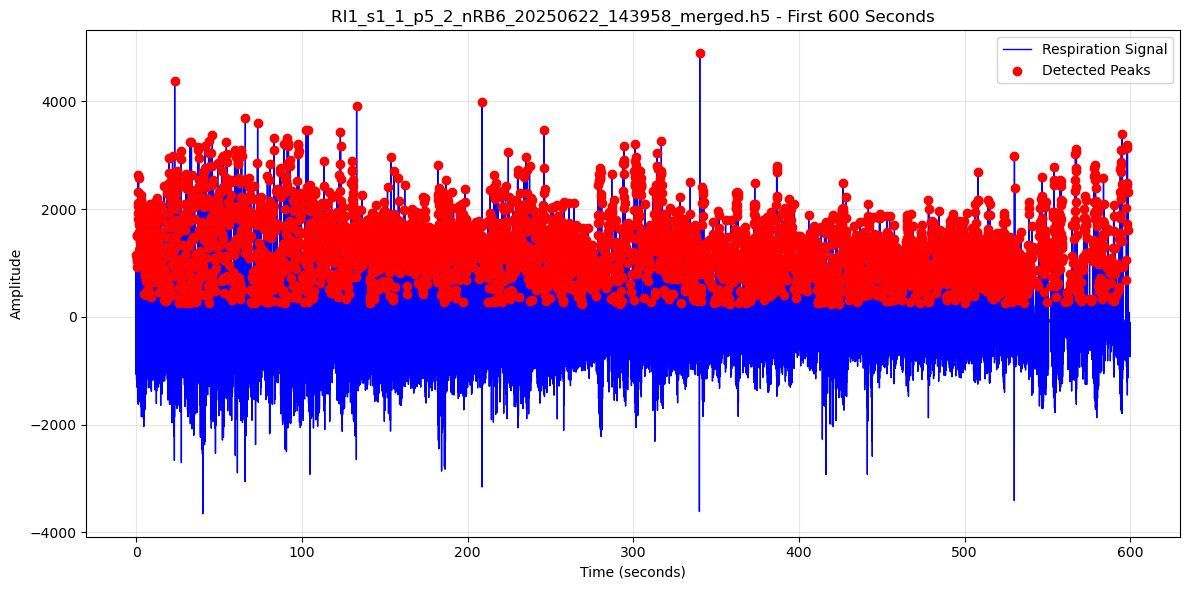

Processing file: RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5


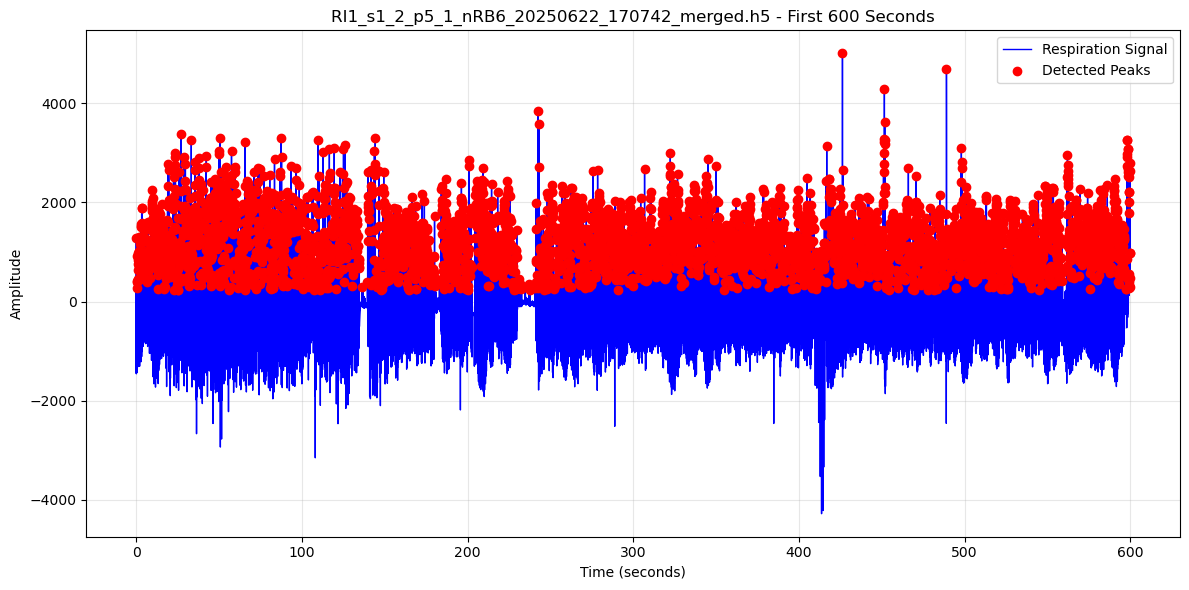

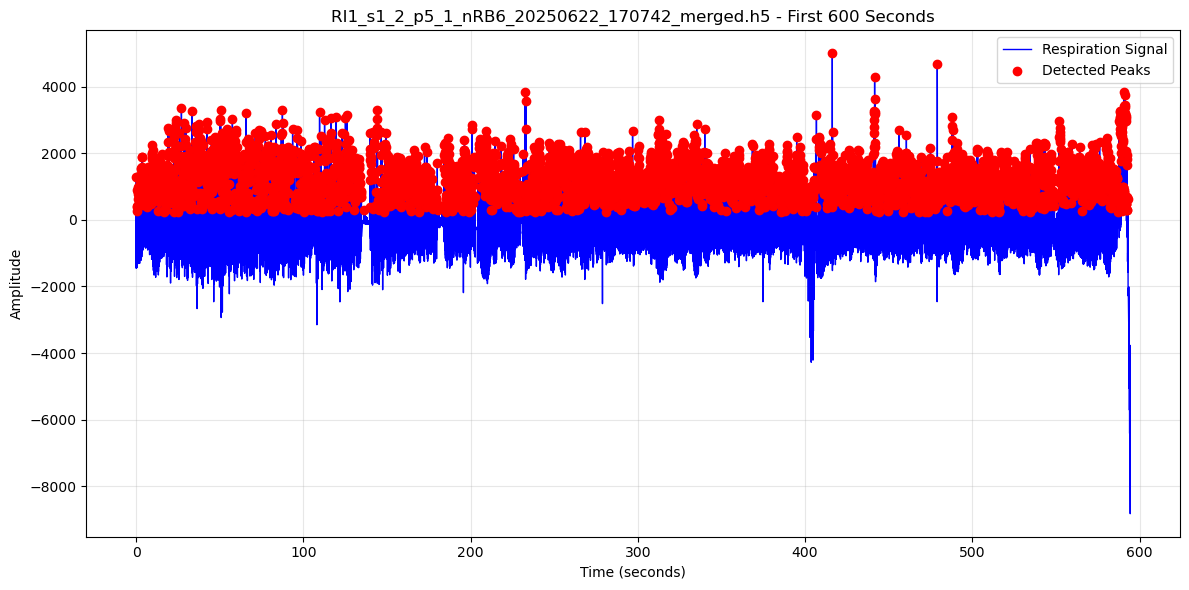

Processing file: RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5


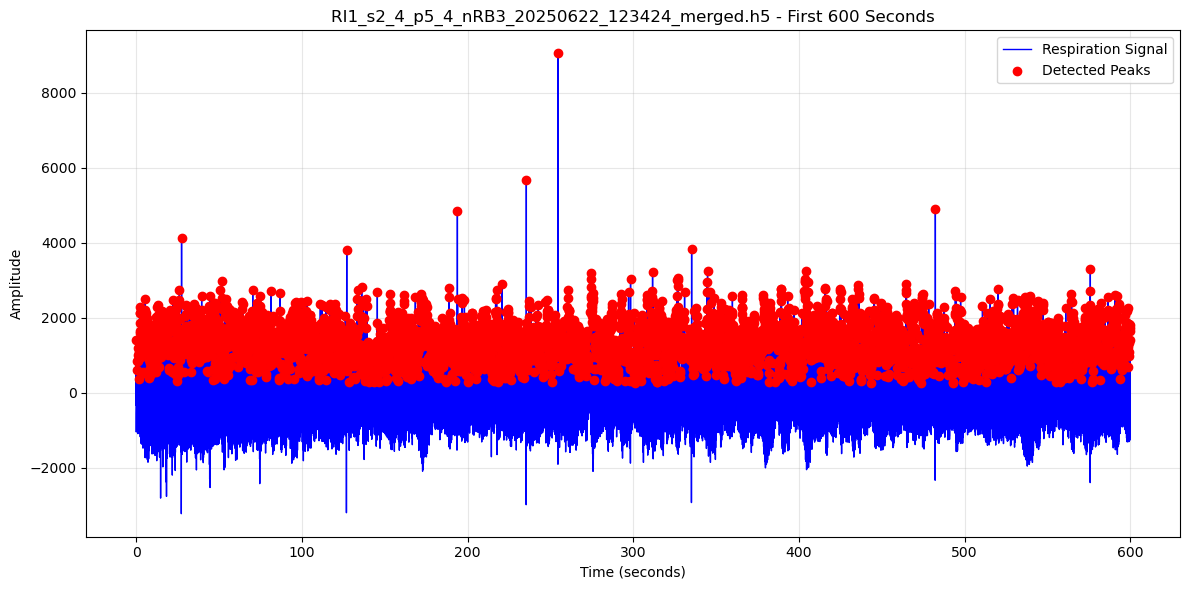

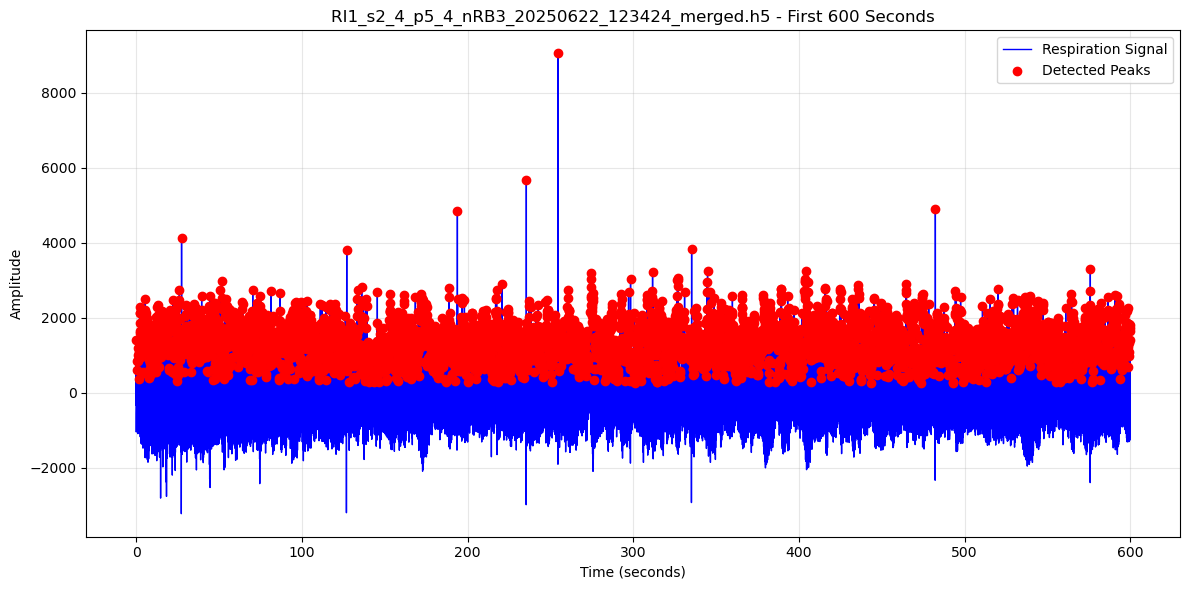

Processing file: RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5


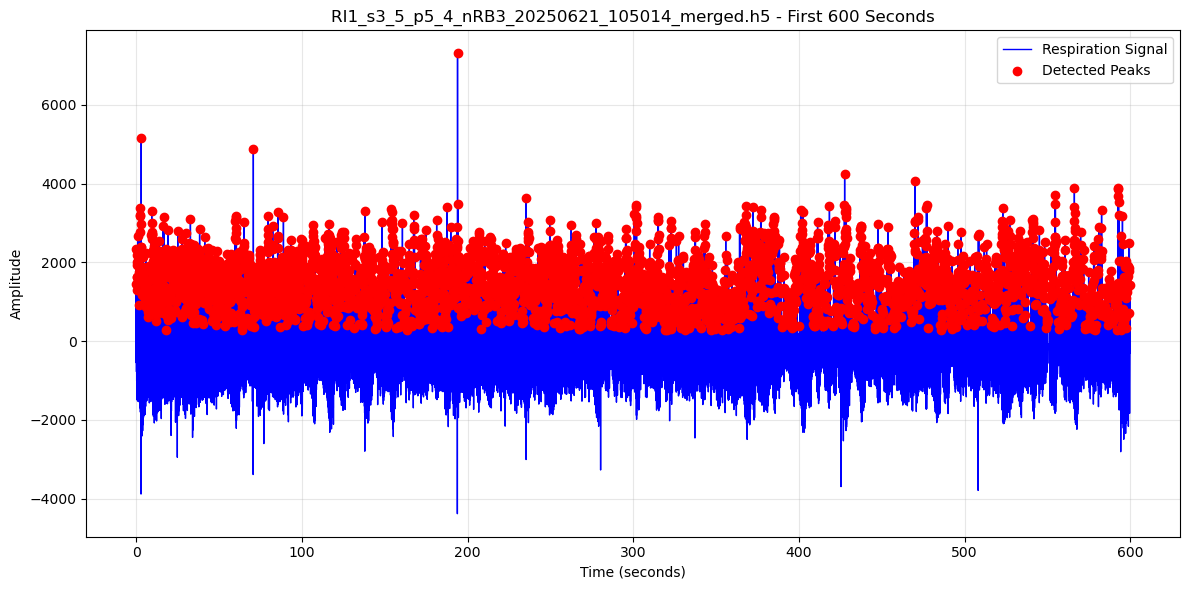

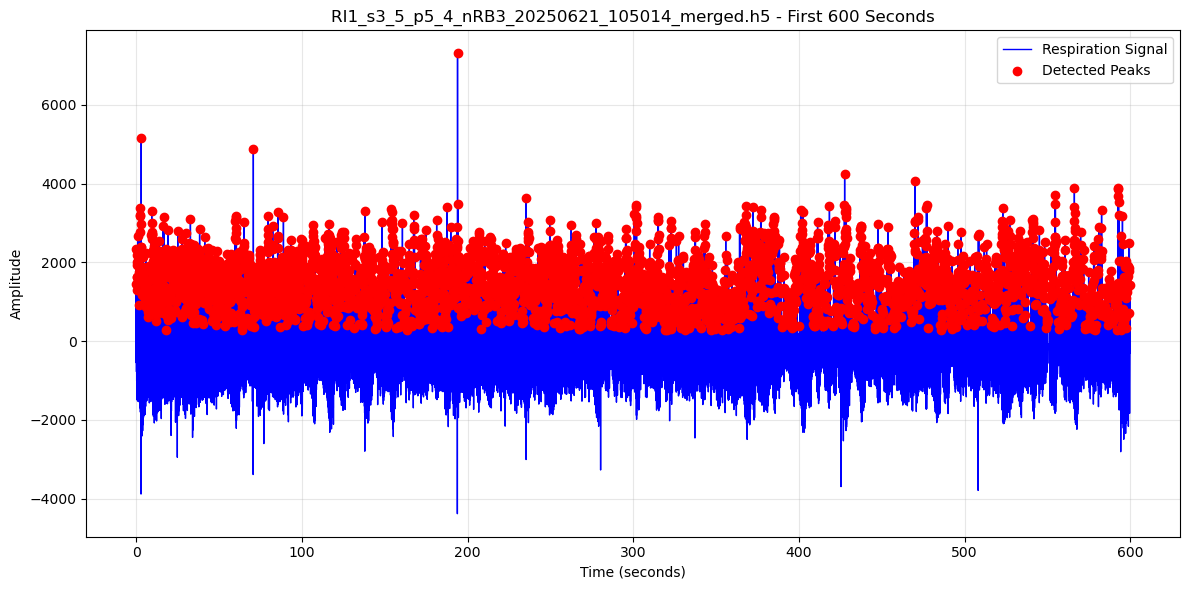

Processing file: RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5


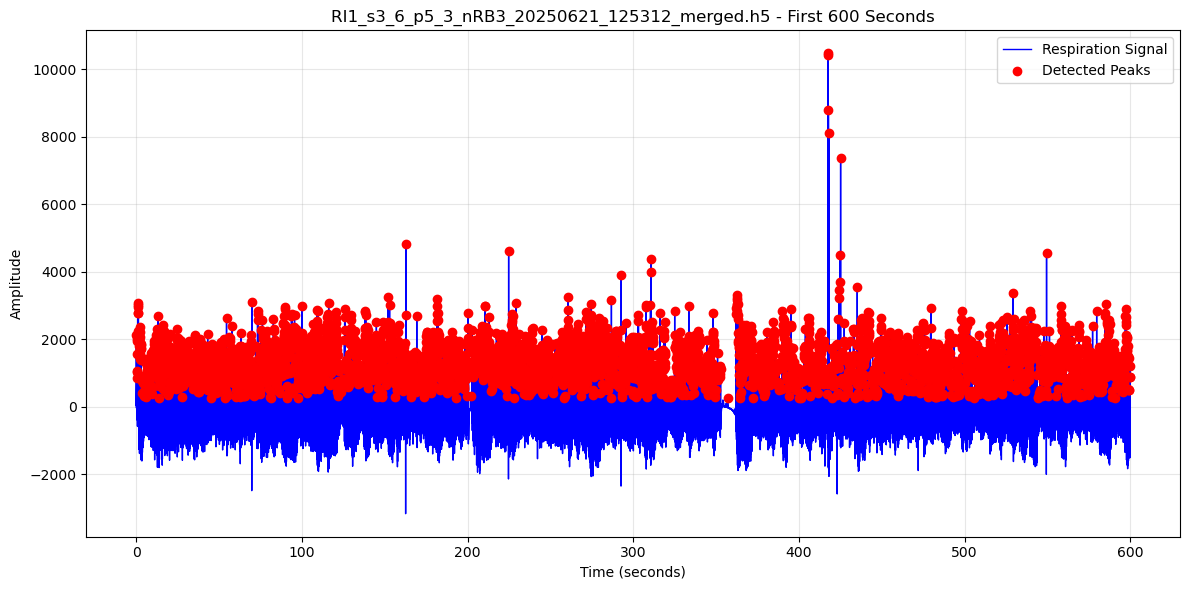

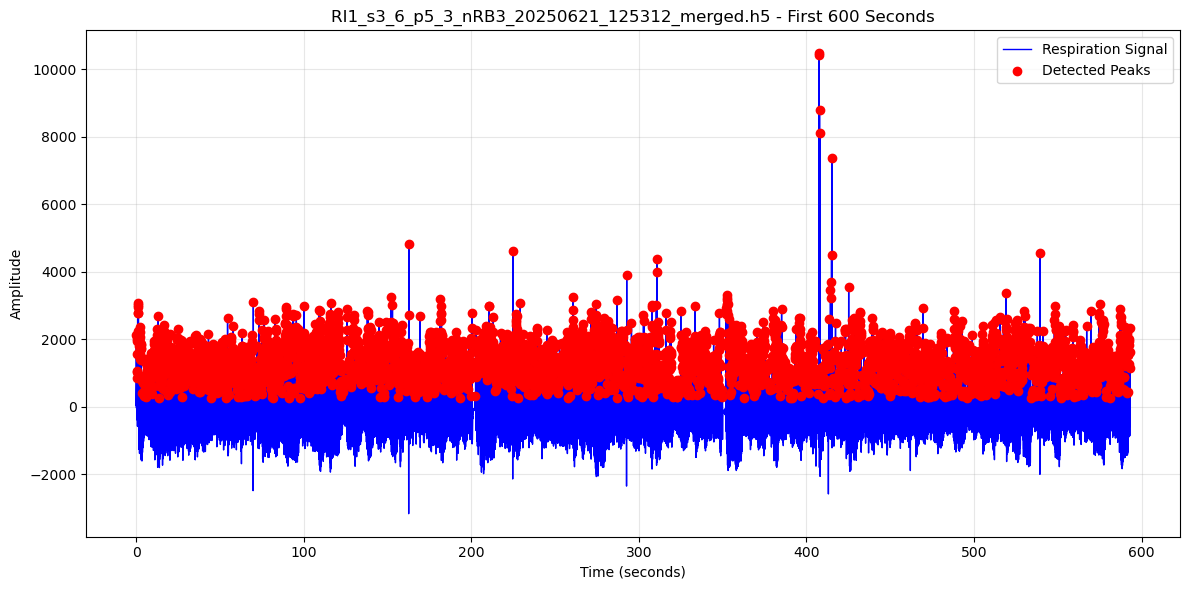

Processing file: RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5


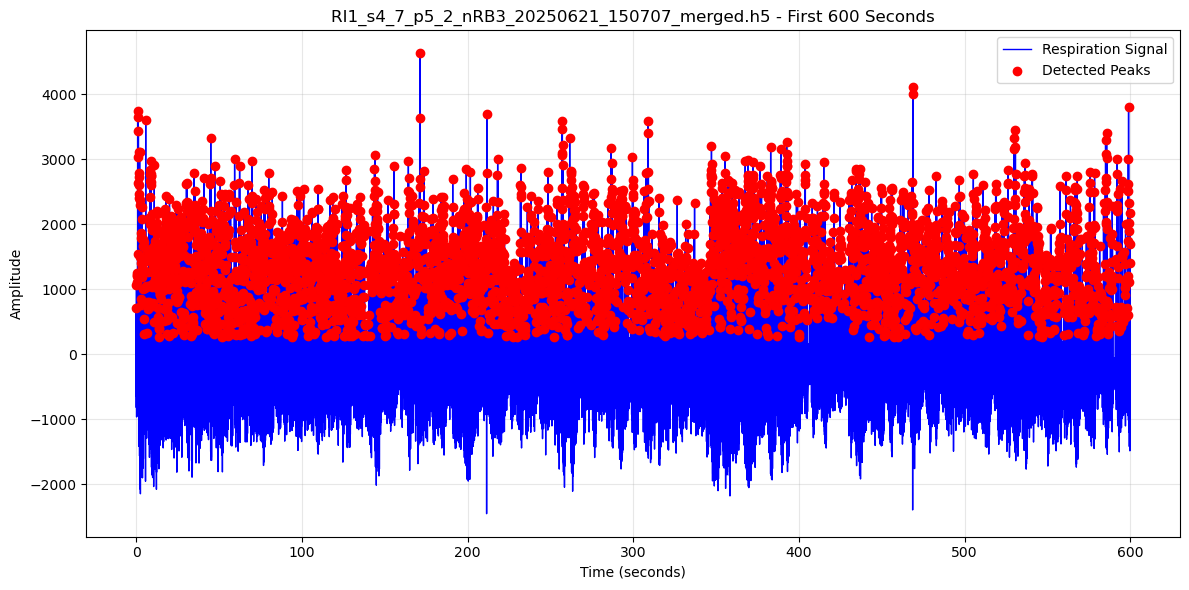

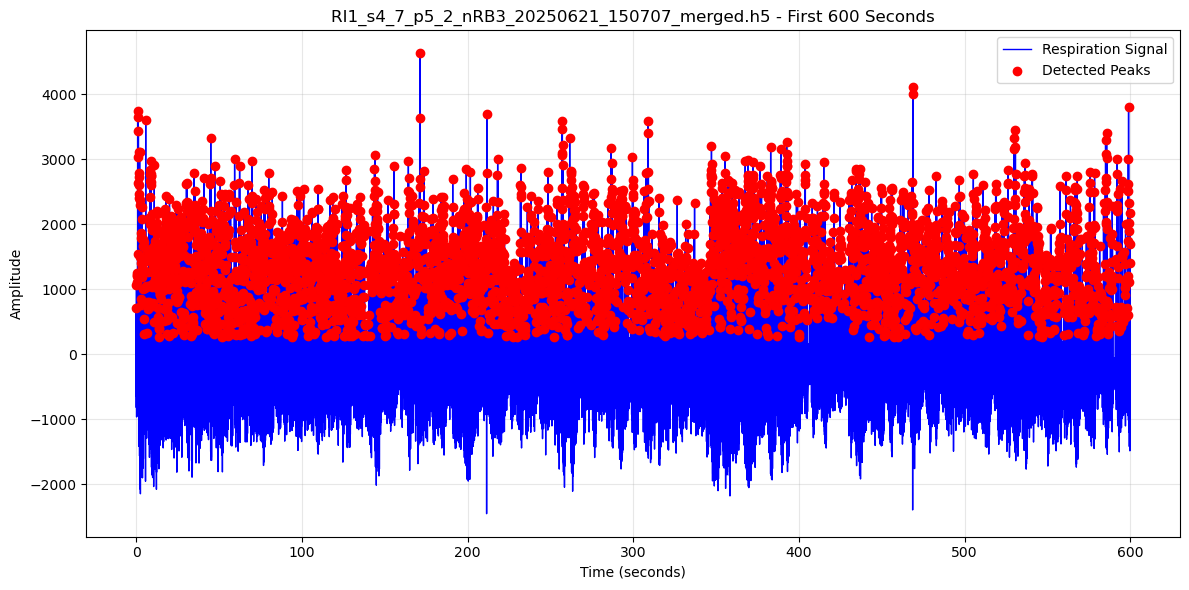

Processing file: RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5


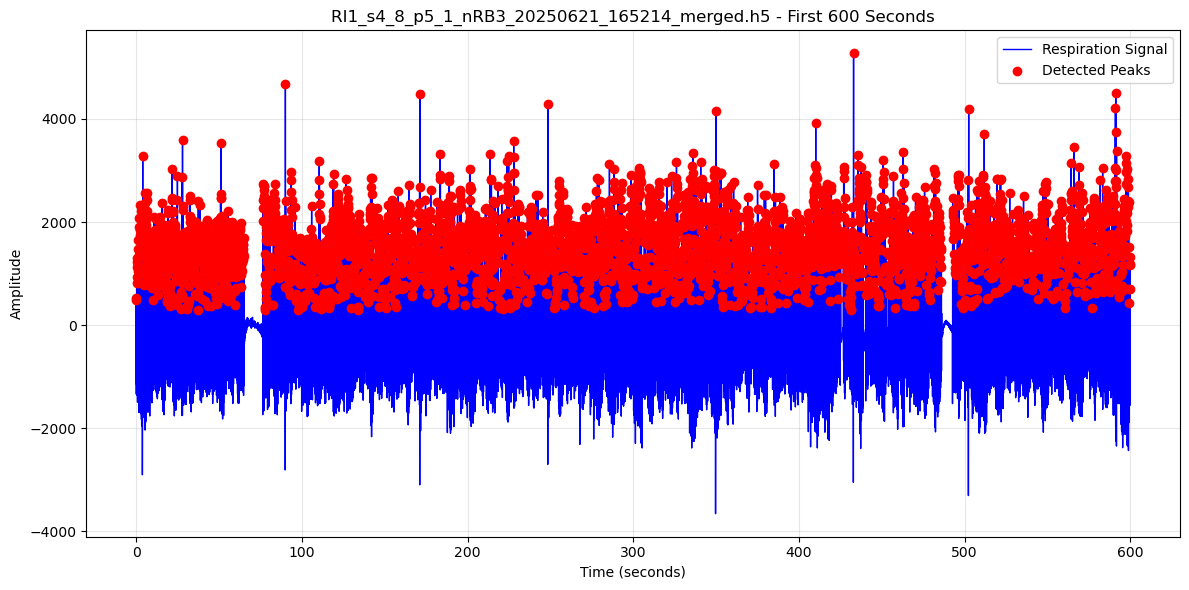

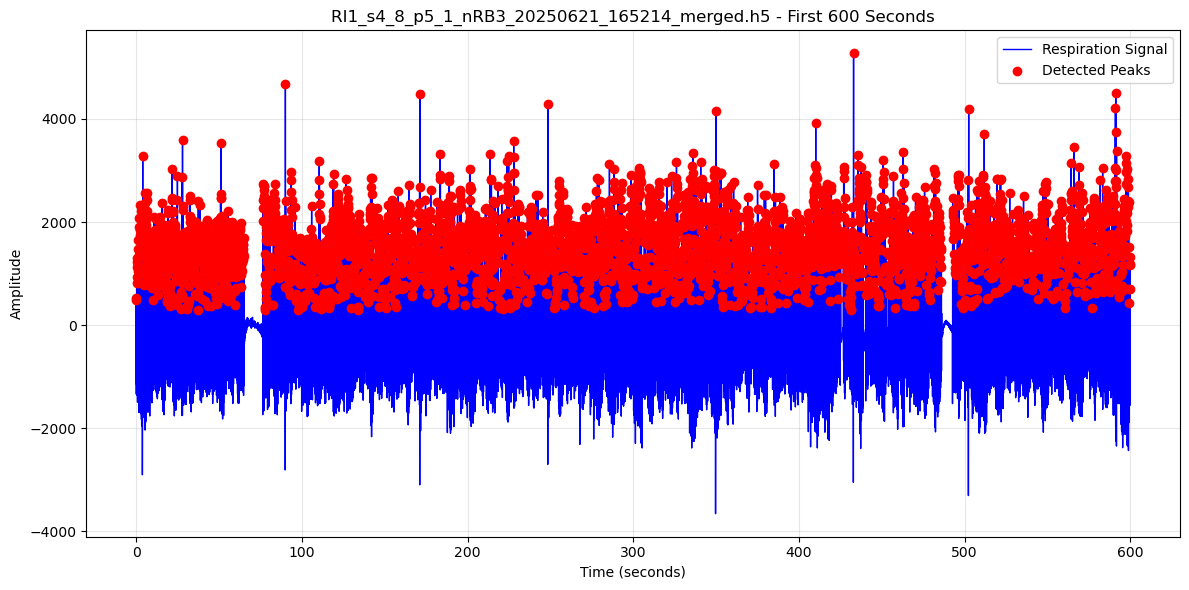

Processing file: RI1_s5_13_p5_4_nRB3_20250622_181801_merged.h5


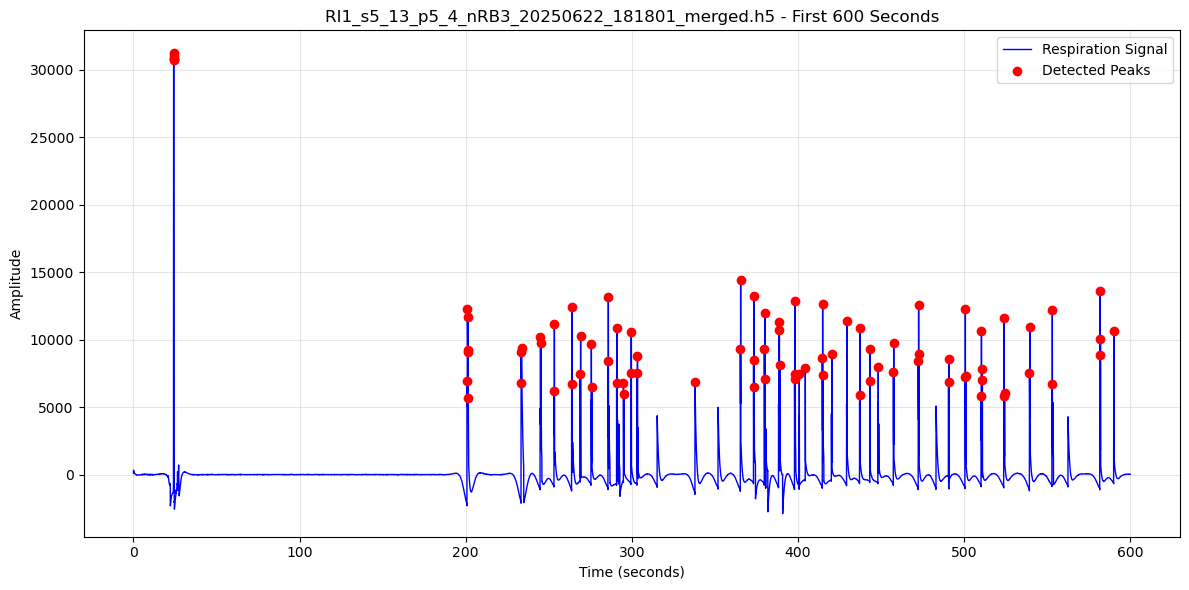

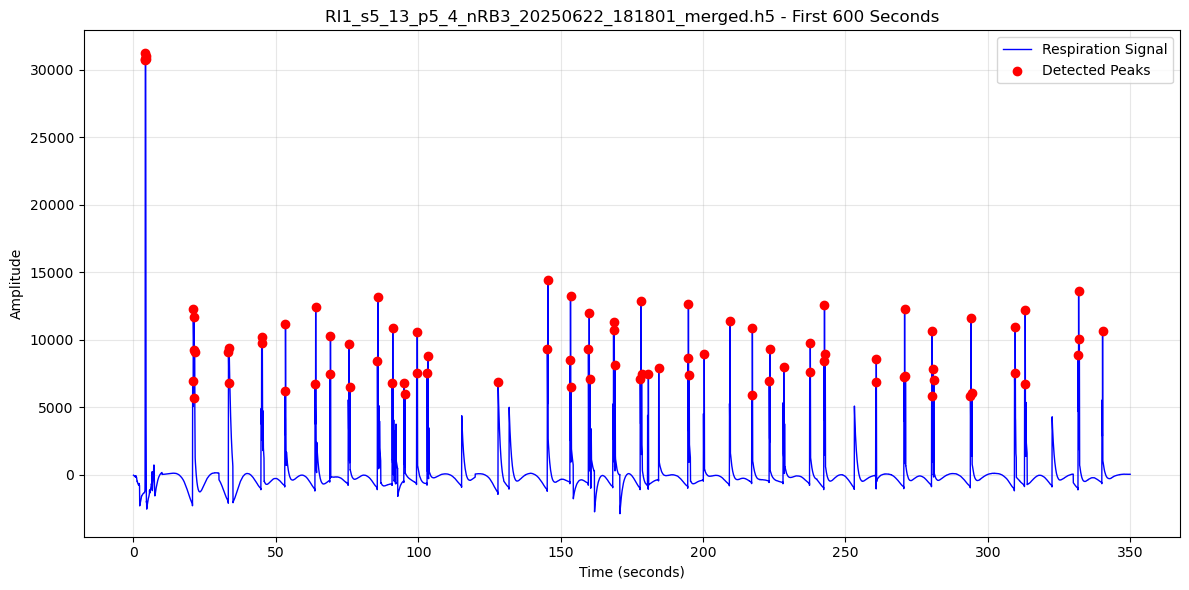

Processing file: RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5


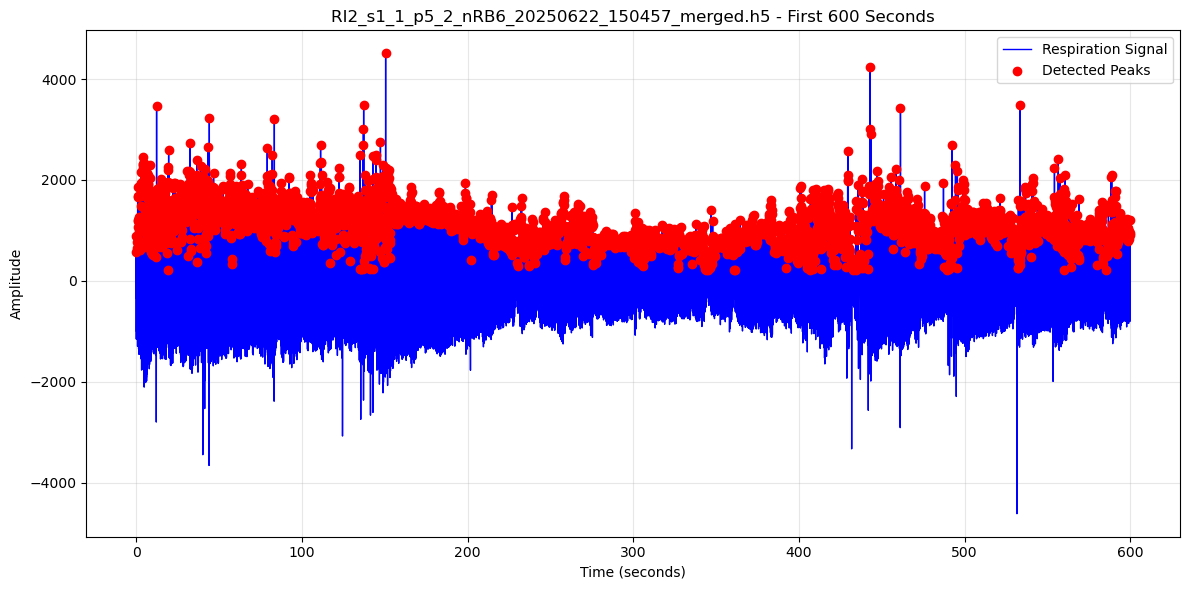

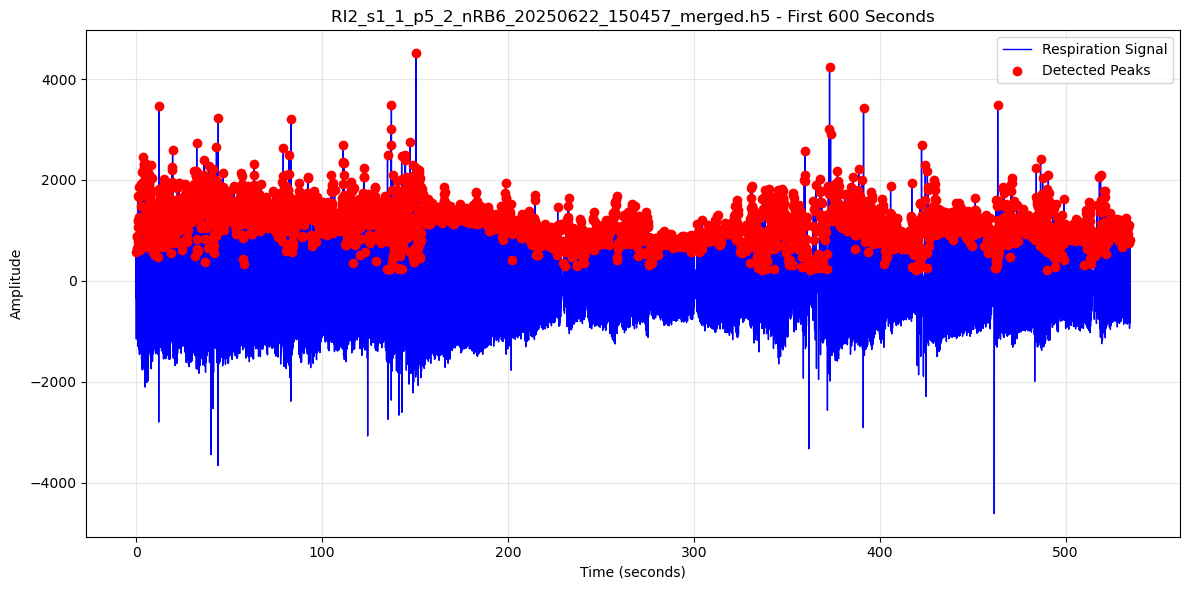

Processing file: RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5


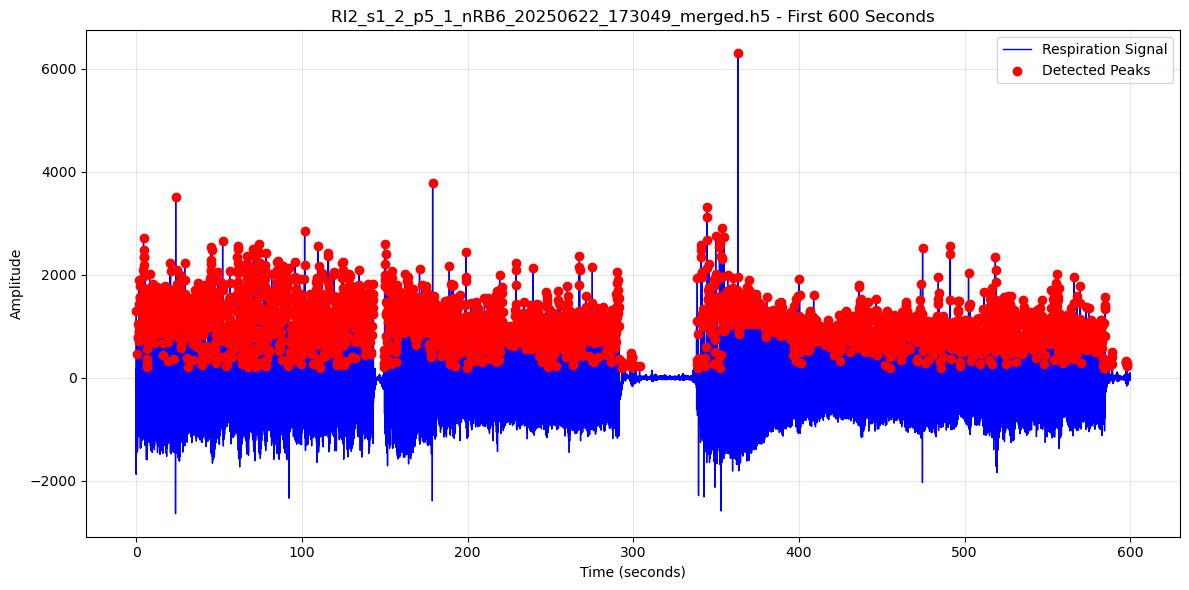

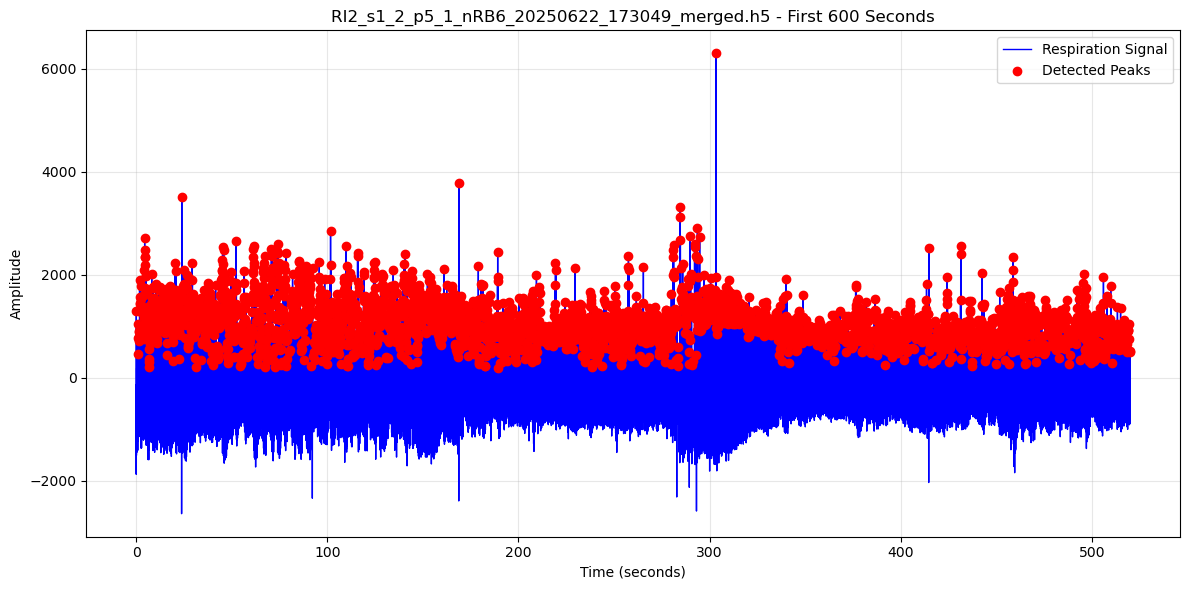

Processing file: RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5


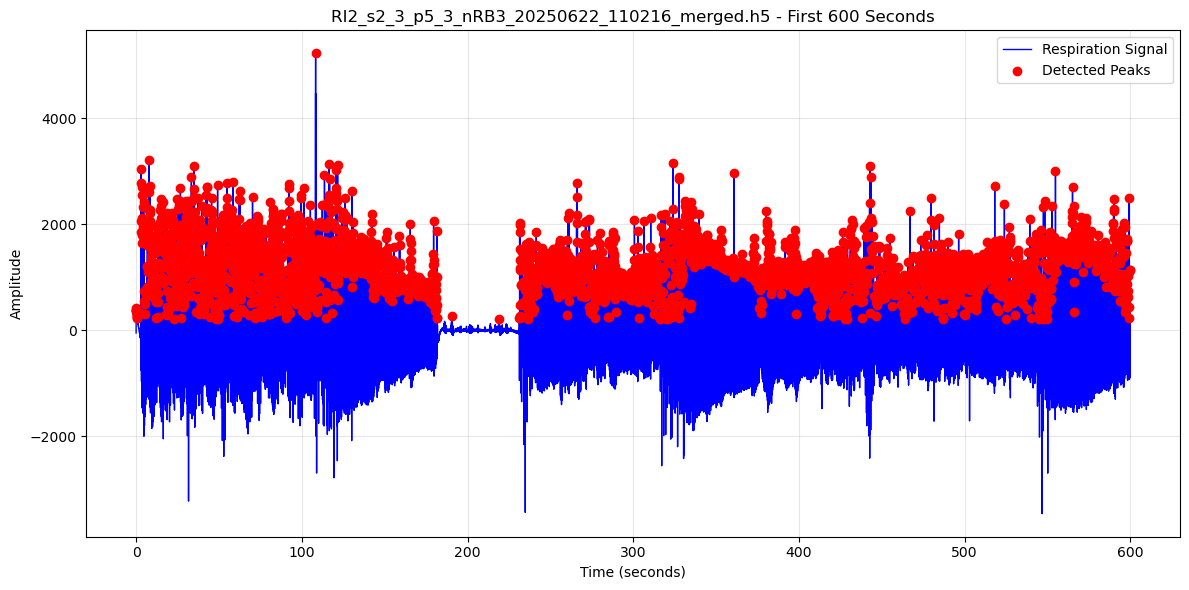

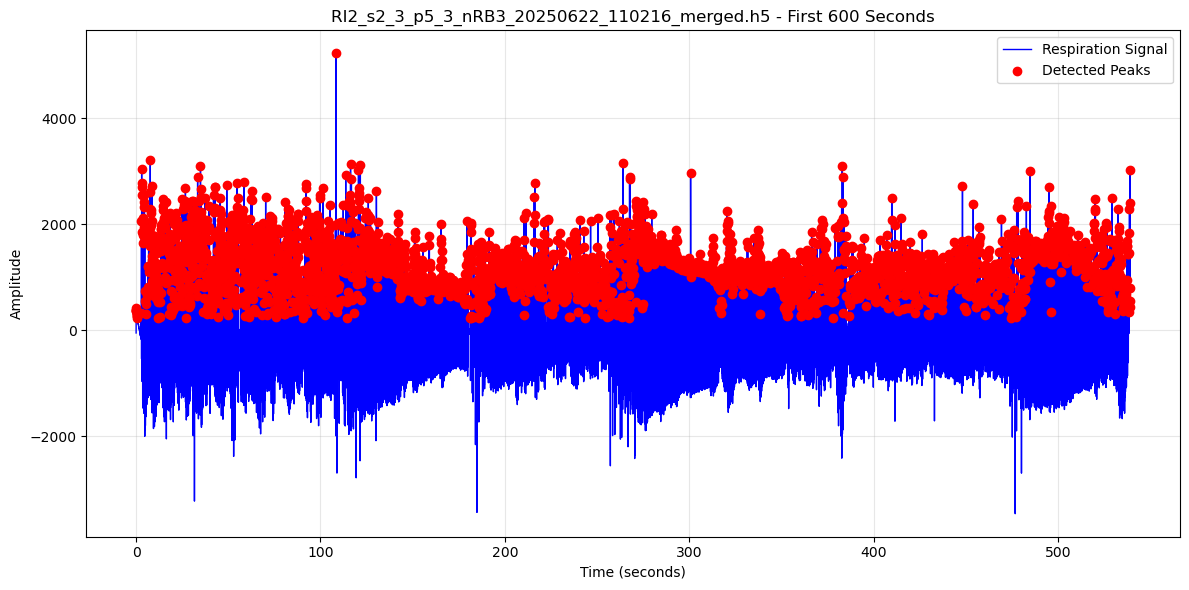

Processing file: RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5


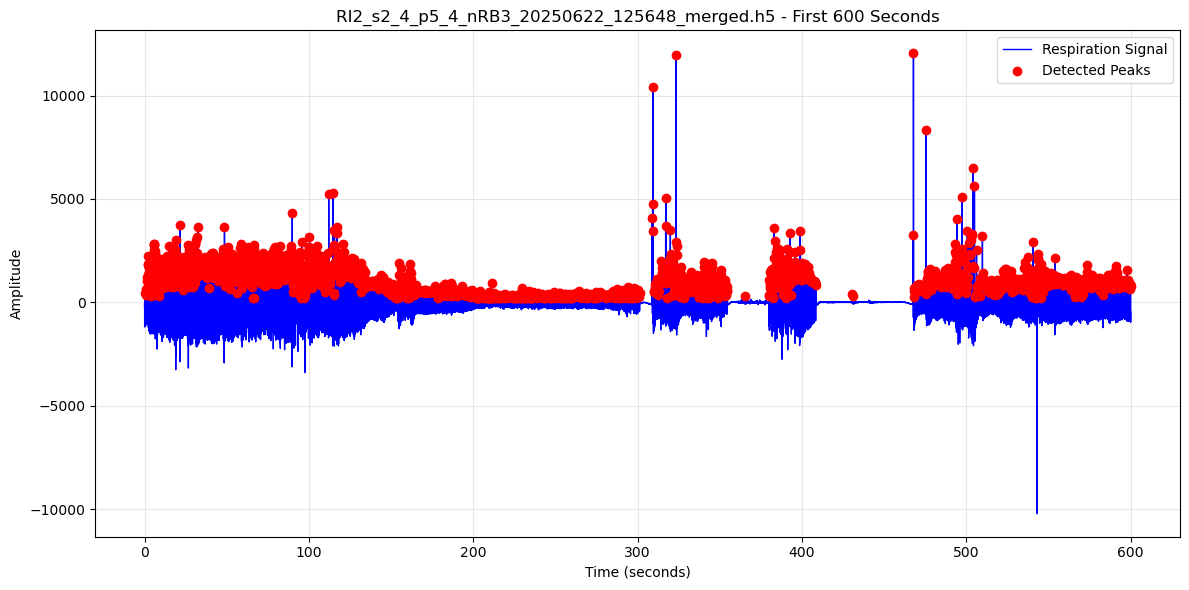

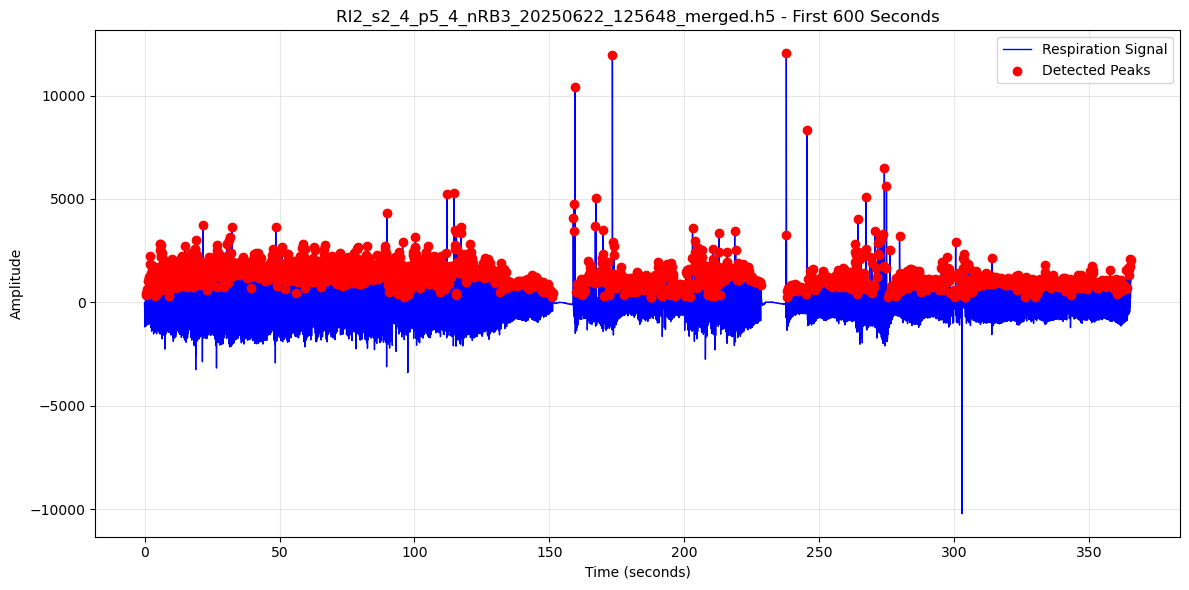

Processing file: RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5


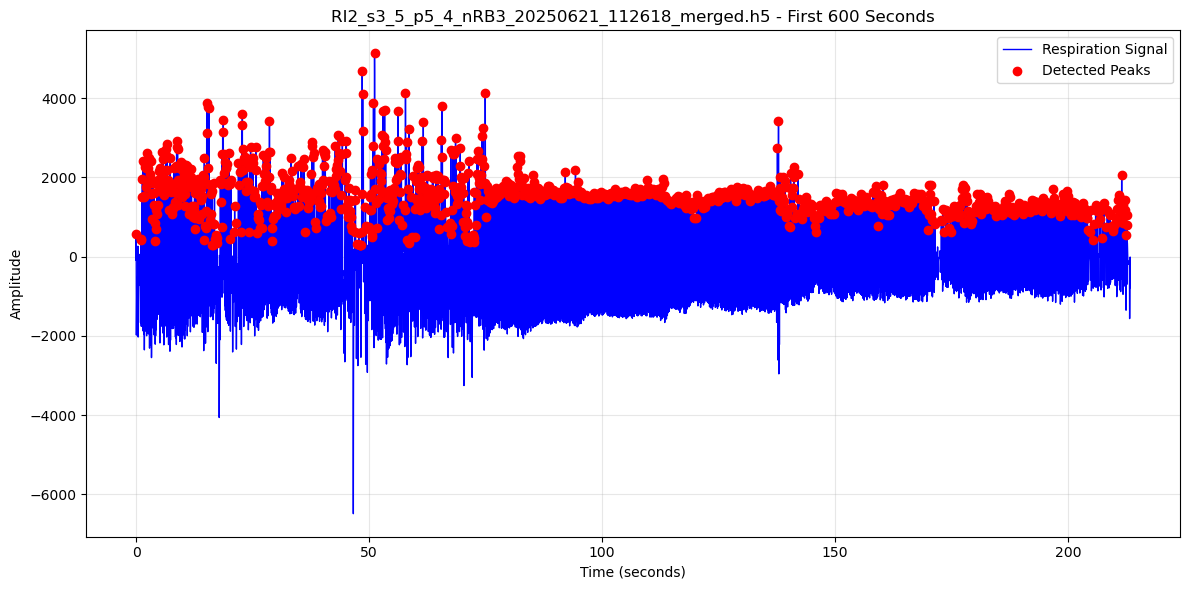

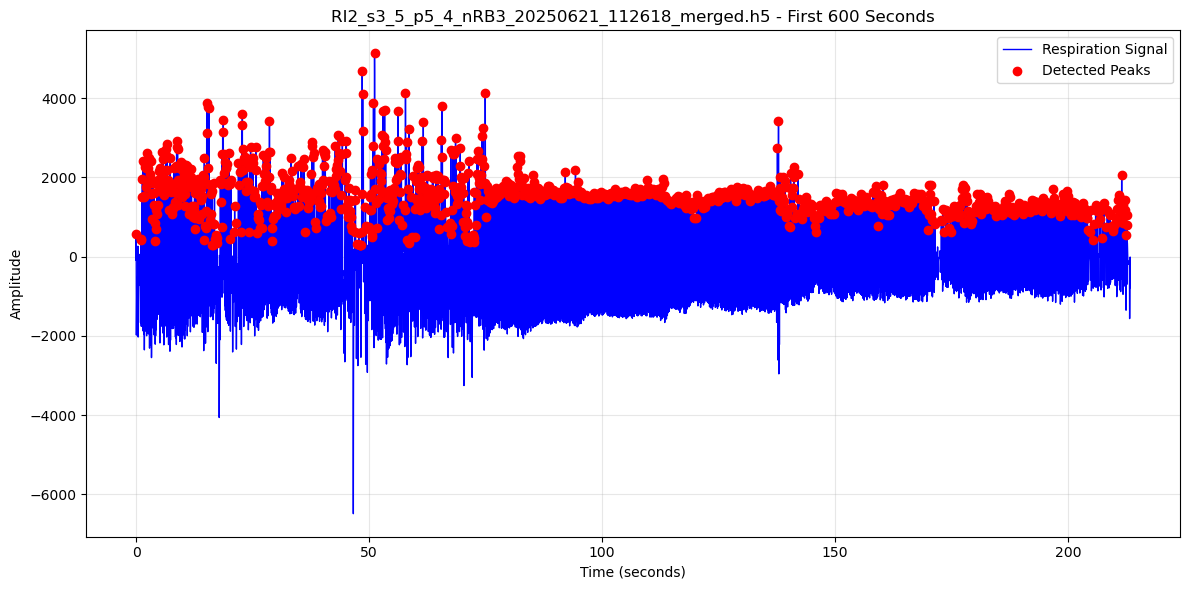

Processing file: RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5


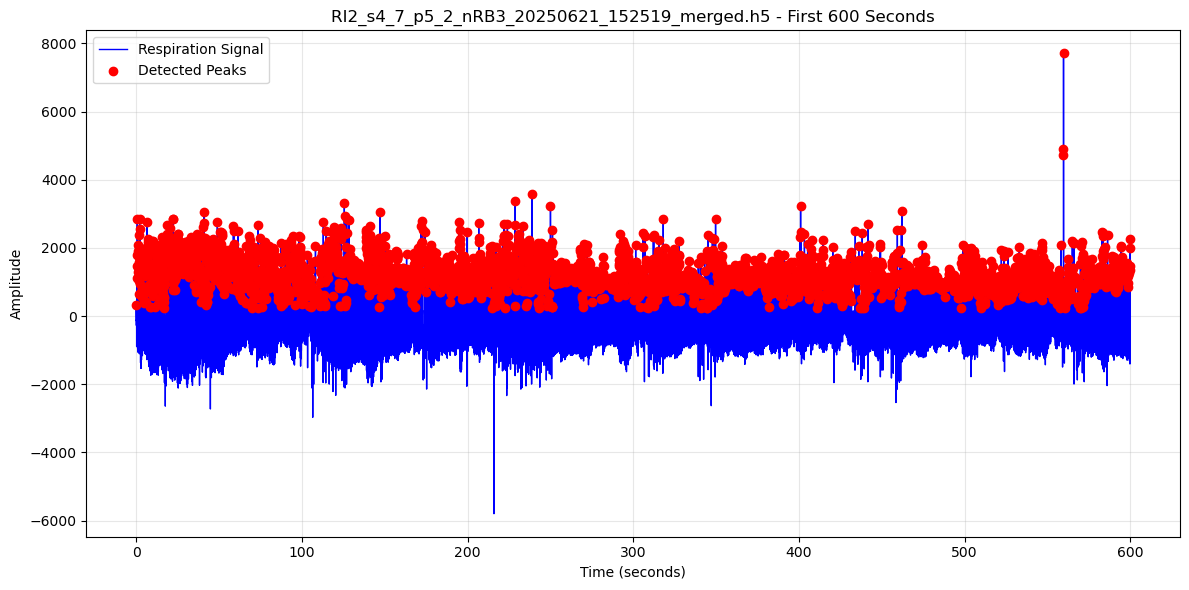

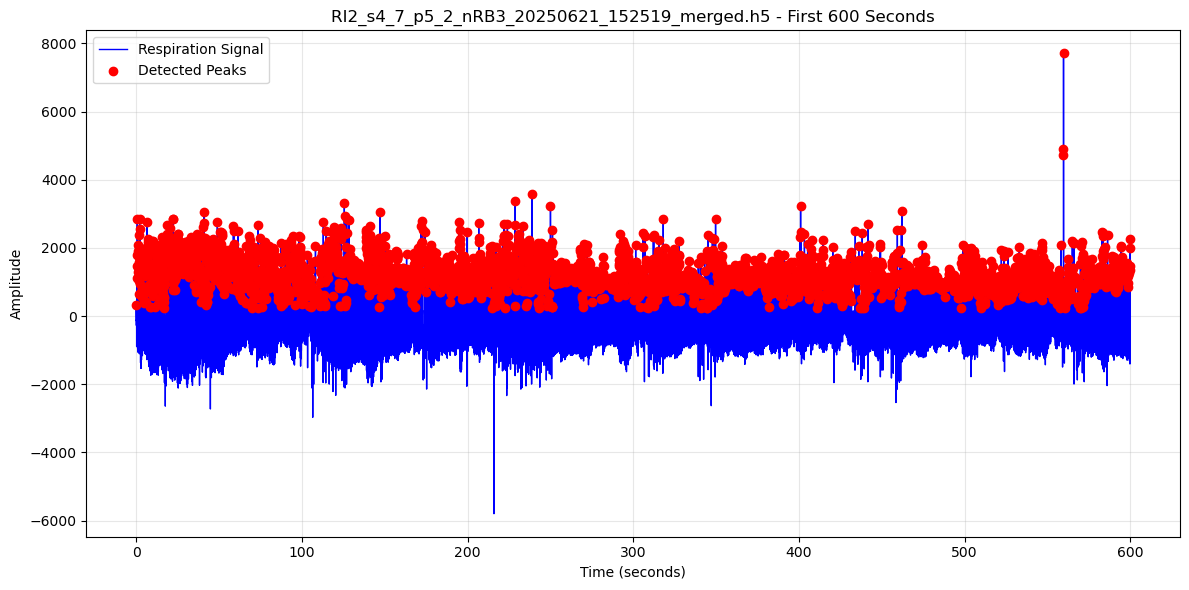

Processing file: RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5


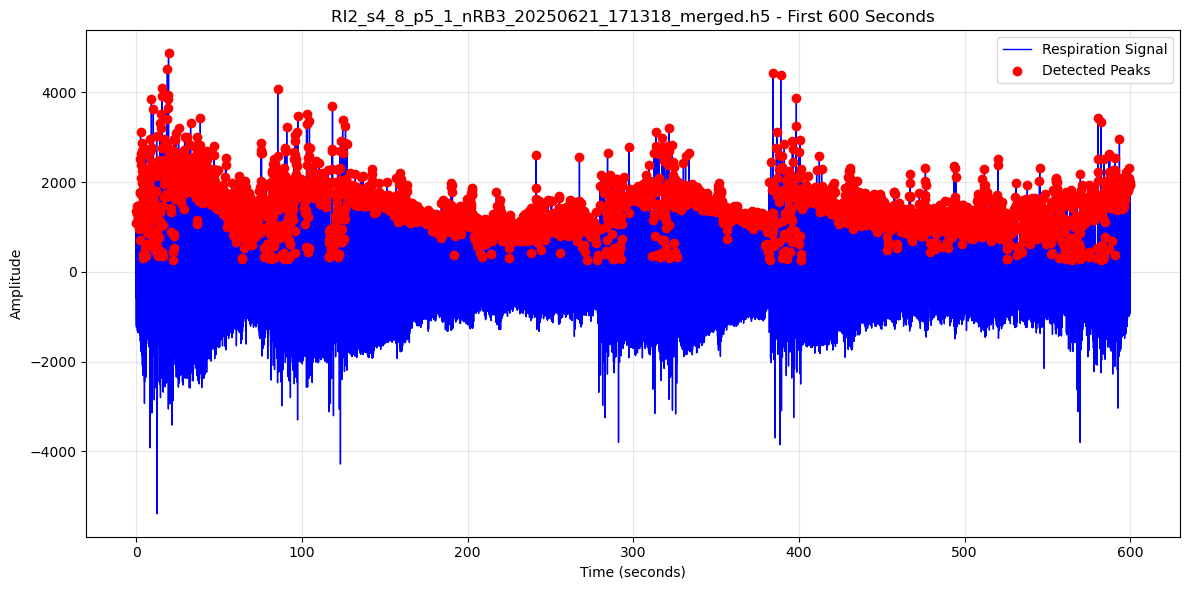

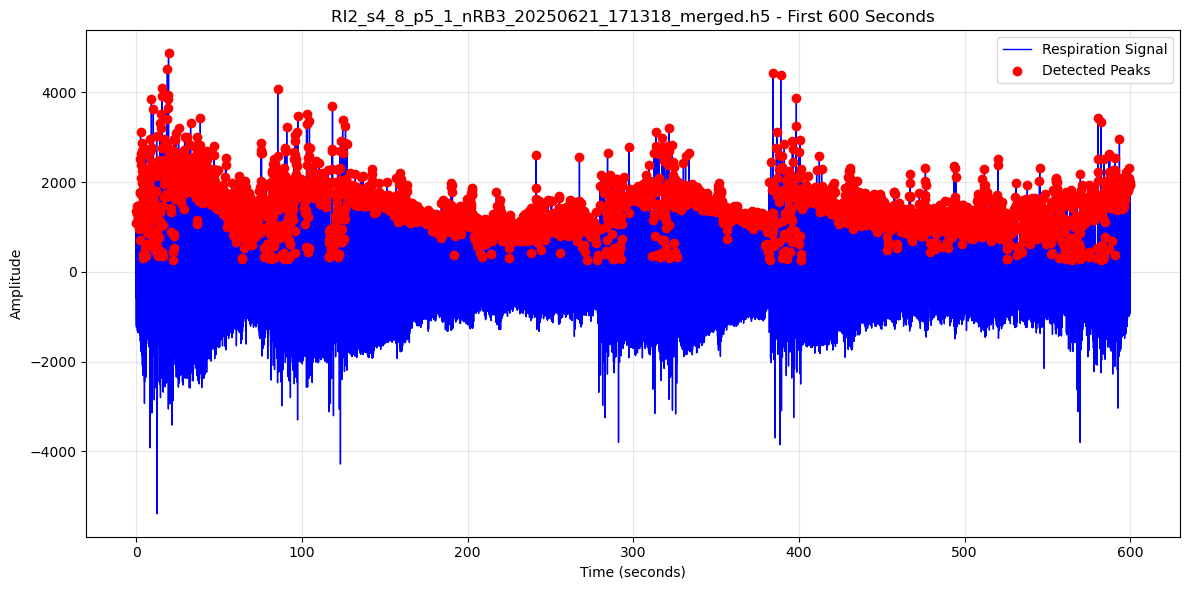

                                          file  original_fs  duration_sec (before downsample and filtering)  filtered_signal_len  duration_valid  peak_count  breathing_rate_hz                                                                                 error
 BLRI_s1_1_p5_2_nRB6_20250622_141846_merged.h5      20000.0                                          632.01              62201.0          622.01      5281.0               8.49                                                                                   NaN
 BLRI_s1_2_p5_1_nRB6_20250622_164833_merged.h5      20000.0                                          610.98              61098.0          610.98      5392.0               8.83                                                                                   NaN
 BLRI_s2_3_p5_3_nRB3_20250622_101813_merged.h5      20000.0                                          608.28              57828.0          578.28      4476.0               7.74                                       

C:\Users\thoma\AppData\Local\Temp\ipykernel_41388\4023427259.py:72: RuntimeWarning: invalid value encountered in scalar divide
  breathing_rate_hz = len(peaks_valid) / duration_valid


In [35]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly, find_peaks
import neurokit2 as nk
import rsp.data_processing.signal_processing as signal_processing
from rsp.plotting import Rsp_Kit

import importlib
importlib.reload(signal_processing)

def analyze_and_plot_breathing(h5_file, target_rate=100):
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
    except Exception as e:
        return {"file": os.path.basename(h5_file), "error": str(e)}

    try:
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except KeyError:
        return {"file": os.path.basename(h5_file), "error": "Missing 'duration_sec' metadata"}

    # Step 1: Pre-downsampling apply low-pass filter
    cutoff_hz = target_rate / 2
    nyquist = fs / 2
    norm_cutoff = cutoff_hz / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Step 2: Downsample
    downsample_factor = int(fs // target_rate)
    downsampled_resp = resample_poly(filtered_resp, up=1, down=downsample_factor)
    duration_downsampled = len(downsampled_resp) / target_rate

    # Step 3: Apply neurokit2 Butterworth bandpass filter after downsampling
    rsp_cleaned = nk.signal_filter(
        downsampled_resp,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Step 4: Mask signal loss with NaN values
    signal_loss_filtered = signal_processing.mask_signal_loss(
        rsp_cleaned,
        fs=target_rate,
        window_sec=10,
        std_thresh=500,
    )

    # Step 5: Subtract total time NaNed from total duration
    total_nan_time = np.sum(np.isnan(signal_loss_filtered)) / target_rate
    duration_downsampled -= total_nan_time

    # Step 6: Peak detection | Change to match how class finds peaks
    # Find valid (non-NaN) indices
    valid = ~np.isnan(signal_loss_filtered)

    # Run peak detection only on valid values
    valid_signal = signal_loss_filtered[valid]
    peaks_valid, _ = find_peaks(valid_signal, distance=target_rate // 20)

    # Calculate valid duration again (just to be sure)
    duration_valid = np.sum(valid) / target_rate
    breathing_rate_hz = len(peaks_valid) / duration_valid

    # Step 5: Plot with Rsp_Kit
    try:
        n_f_rsp = Rsp_Kit.Rsp_Kit(rsp_cleaned, fs=target_rate, n_samples=len(rsp_cleaned))
        rsp_obj = Rsp_Kit.Rsp_Kit(valid_signal, fs=target_rate, n_samples=len(valid_signal))
        print(f"Processing file: {os.path.basename(h5_file)}")
        
        fig1 = n_f_rsp.plot(duration=600, show_peaks=True, title=os.path.basename(h5_file))
        fig2 = rsp_obj.plot(duration=600, show_peaks=True, title=os.path.basename(h5_file))
        plt.close()
    except Exception as plot_err:
        return {"file": os.path.basename(h5_file), "error": f"Plotting failed: {plot_err}"}

    return {
        "file": os.path.basename(h5_file),
        "original_fs": round(fs, 2),
        "duration_sec (before downsample and filtering)": round(duration_sec, 2),
        "filtered_signal_len": len(valid_signal),
        "duration_valid": round(duration_valid, 2),
        "peak_count": len(peaks_valid),
        "breathing_rate_hz": round(breathing_rate_hz, 2),
    }

def batch_analyze_directory(directory_path):
    results = []
    for file in os.listdir(directory_path):
        if file.endswith(".h5"):
            full_path = os.path.join(directory_path, file)
            result = analyze_and_plot_breathing(full_path)
            results.append(result)
    return pd.DataFrame(results)

# 👉 SET YOUR DIRECTORY PATH HERE
if __name__ == "__main__":
    directory = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\updated_meta_h5"
    df_results = batch_analyze_directory(directory)
    print(df_results.to_string(index=False))
